## Tanzima Mohommadyasin Shaikh

Use a pretrained VGG model for transfer learning. Unfreeze certain layers of the base network and apply fine-tuning to adapt the model to the new dataset.


In [1]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam


In [10]:
base_dir = '.'  

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 5  


In [98]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.8  # only use 20% for training
)

train_data = datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=(224, 224),
    batch_size=32,
    subset='training'
)

val_data = datagen.flow_from_directory(
    os.path.join(base_dir, 'val'),
    target_size=(224, 224),
    batch_size=32,
    subset='validation'
)





Found 2669 images belonging to 5 classes.
Found 3334 images belonging to 5 classes.


In [18]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras import layers

# Load VGG16 without classifier head
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all layers initially
for layer in vgg_base.layers:
    layer.trainable = False


In [5]:
# Add custom classification layers
x = vgg_base.output
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(5, activation='softmax')(x)  # 5 classes: food, drink, inside, outside, menu

# Combine VGG base with new head
model = Model(inputs=vgg_base.input, outputs=output)


In [6]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

checkpoint = ModelCheckpoint(
    'vgg16_frozen_best.h5',  # Saves the best model
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)


In [14]:
history = model.fit(
    train_data,
# You can increase if needed
    validation_data=val_data,
    epochs=5,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/5
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9124 - loss: 0.2479

451/451 ━━━━━━━━━━━━━━━━━━━━ 2445s 5s/step - accuracy: 0.9124 - loss: 0.2479 - val_accuracy: 0.8880 - val_loss: 0.3066
Epoch 2/5
451/451 ━━━━━━━━━━━━━━━━━━━━ 2281s 5s/step - accuracy: 0.9337 - loss: 0.1919 - val_accuracy: 0.8841 - val_loss: 0.3201
Epoch 3/5
451/451 ━━━━━━━━━━━━━━━━━━━━ 2278s 5s/step - accuracy: 0.9370 - loss: 0.1733 - val_accuracy: 0.8805 - val_loss: 0.3346
Epoch 4/5
451/451 ━━━━━━━━━━━━━━━━━━━━ 2047s 5s/step - accuracy: 0.9470 - loss: 0.1546 - val_accuracy: 0.8827 - val_loss: 0.3336


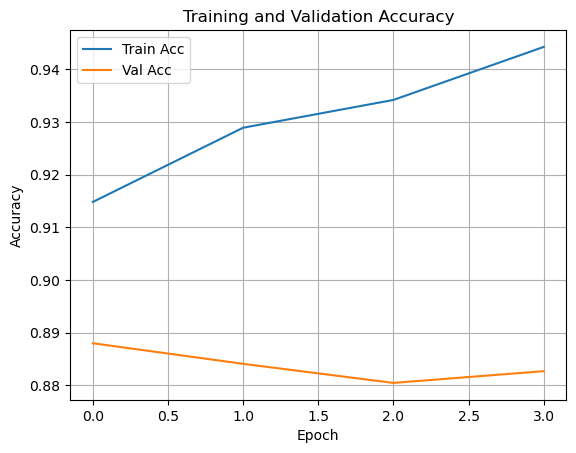

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [19]:
loss, acc = model.evaluate(test_data)
print(f"Test Accuracy: {acc:.4f} — Loss: {loss:.4f}")


281/281 ━━━━━━━━━━━━━━━━━━━━ 922s 3s/step - accuracy: 0.8996 - loss: 0.2862
Test Accuracy: 0.8909 — Loss: 0.3022


In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get true labels
y_true = test_data.classes

# Predict
y_pred_probs = model.predict(test_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# Print report
print("Classification Report:\n", classification_report(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))


281/281 ━━━━━━━━━━━━━━━━━━━━ 1114s 4s/step
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.89      1568
           1       0.95      0.95      0.95      2643
           2       0.85      0.89      0.87      2749
           3       0.92      0.81      0.86       167
           4       0.86      0.84      0.85      1857

    accuracy                           0.89      8984
   macro avg       0.90      0.87      0.88      8984
weighted avg       0.89      0.89      0.89      8984

Confusion Matrix:
 [[1371   60  113    1   23]
 [  72 2507   47    1   16]
 [  55   53 2440    4  197]
 [   1    9   12  135   10]
 [  17   12  272    5 1551]]


## Iteration 2

In [22]:
import os

base_dir = '.'

def count_images(folder):
    total = 0
    for subdir in os.listdir(folder):
        sub_path = os.path.join(folder, subdir)
        if os.path.isdir(sub_path):
            total += len(os.listdir(sub_path))
    return total

train_count = count_images(os.path.join(base_dir, 'train'))
val_count = count_images(os.path.join(base_dir, 'val'))
test_count = count_images(os.path.join(base_dir, 'test'))

print(f"Train images: {train_count}")
print(f" Validation images: {val_count}")
print(f" Test images: {test_count}")
print(f"Total images used: {train_count + val_count + test_count}")


Train images: 72017
 Validation images: 8964
 Test images: 8984
Total images used: 89965


In [23]:
import os

# List top-level folders
print("Top-level items:")
print(os.listdir('.'))


Top-level items:
['.DS_Store', 'test', 'VGG Model.ipynb', 'train', '.ipynb_checkpoints', 'vgg16_frozen_best.h5', 'val']


In [42]:
for class_name in os.listdir(original_train):
    class_path = os.path.join(original_train, class_name)
    if not os.path.isdir(class_path) or class_name.startswith('.'):
        continue


In [43]:
!find . -name '.DS_Store' -type f -delete


In [45]:
import os, shutil, random

# Original full data directory
original_train = './train'
original_val = './val'

# New smaller dataset directory
new_base = 'dataset_small'

# Desired count
train_per_class = 3000  # 3000 x 5 = 15,000
val_per_class = 1000    # 1000 x 5 = 5,000

# Delete old if exists
if os.path.exists(new_base):
    shutil.rmtree(new_base)

# Create new directories
for split in ['train', 'val']:
    for class_name in os.listdir(original_train):
        os.makedirs(os.path.join(new_base, split, class_name), exist_ok=True)

# Copy train images
for class_name in os.listdir(original_train):
    src = os.path.join(original_train, class_name)
    dst = os.path.join(new_base, 'train', class_name)
    imgs = [f for f in os.listdir(src) if f.lower().endswith(('.jpg', '.png'))]
    selected = random.sample(imgs, min(train_per_class, len(imgs)))
    for f in selected:
        shutil.copy(os.path.join(src, f), os.path.join(dst, f))

# Copy val images
for class_name in os.listdir(original_val):
    src = os.path.join(original_val, class_name)
    dst = os.path.join(new_base, 'val', class_name)
    imgs = [f for f in os.listdir(src) if f.lower().endswith(('.jpg', '.png'))]
    selected = random.sample(imgs, min(val_per_class, len(imgs)))
    for f in selected:
        shutil.copy(os.path.join(src, f), os.path.join(dst, f))

print("New dataset_small/ created with 15K train and 5K val images.")


New dataset_small/ created with 15K train and 5K val images.


In [48]:
import os

base_dir = 'dataset_small'

for split in ['train', 'val']:
    print(f"\n{split.upper()} FOLDER:")
    total = 0
    for class_name in os.listdir(os.path.join(base_dir, split)):
        class_path = os.path.join(base_dir, split, class_name)
        if os.path.isdir(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])
            print(f"{class_name}: {count} images")
            total += count
    print(f"TOTAL {split} images: {total}")



TRAIN FOLDER:
outside: 3000 images
inside: 3000 images
menu: 1343 images
food: 3000 images
drink: 3000 images
TOTAL train images: 13343

VAL FOLDER:
outside: 1000 images
inside: 1000 images
menu: 168 images
food: 1000 images
drink: 1000 images
TOTAL val images: 4168


In [47]:
import os

# Check top-level folders
print("Top-level folders:")
print(os.listdir('.'))


Top-level folders:
['test', 'VGG Model.ipynb', 'train', '.ipynb_checkpoints', 'vgg16_frozen_best.h5', 'val', 'dataset_small']


In [27]:
base_dir = 'dataset_small'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [49]:
# ImageDataGenerator with data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

In [50]:
val_datagen = ImageDataGenerator(rescale=1./255)

In [51]:
# Data loaders
train_data = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

Found 13343 images belonging to 5 classes.


In [52]:
val_data = val_datagen.flow_from_directory(
    os.path.join(base_dir, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4168 images belonging to 5 classes.


In [58]:
from tensorflow.keras import models, layers, optimizers, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout


In [59]:
# Load VGG16 base (without top layers)
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg_base.trainable = False  


In [60]:
# Build model
model = Sequential([
    vgg_base,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),                     
    Dense(train_data.num_classes, activation='softmax')
])


In [ ]:

model = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),  # L2 REGULARIZATION
    layers.Dropout(0.5),  # DROPOUT
    layers.Dense(train_data.num_classes, activation='softmax')
])


In [61]:
# Compile
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])


In [62]:
# Callbacks
early_stop = EarlyStopping(patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('vgg16_iter2_best.h5', save_best_only=True)


In [65]:
# Train
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7891 - loss: 0.5675

417/417 ━━━━━━━━━━━━━━━━━━━━ 1884s 5s/step - accuracy: 0.7891 - loss: 0.5674 - val_accuracy: 0.8472 - val_loss: 0.4091
Epoch 2/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8238 - loss: 0.4741

417/417 ━━━━━━━━━━━━━━━━━━━━ 2151s 5s/step - accuracy: 0.8238 - loss: 0.4741 - val_accuracy: 0.8577 - val_loss: 0.3918
Epoch 3/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8287 - loss: 0.4577

417/417 ━━━━━━━━━━━━━━━━━━━━ 1924s 5s/step - accuracy: 0.8287 - loss: 0.4577 - val_accuracy: 0.8678 - val_loss: 0.3638
Epoch 4/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 2109s 5s/step - accuracy: 0.8468 - loss: 0.4183 - val_accuracy: 0.8558 - val_loss: 0.3838
Epoch 5/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8524 - loss: 0.4090

417/417 ━━━━━━━━━━━━━━━━━━━━ 2176s 5s/step - accuracy: 0.8524 - loss: 0.4090 - val_accuracy: 0.8632 - val_loss: 0.3509


In [66]:
val_loss, val_acc = model.evaluate(val_data)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Loss: {val_loss:.4f}")


131/131 ━━━━━━━━━━━━━━━━━━━━ 530s 4s/step - accuracy: 0.8900 - loss: 0.2962
Validation Accuracy: 0.8632
Validation Loss: 0.3509


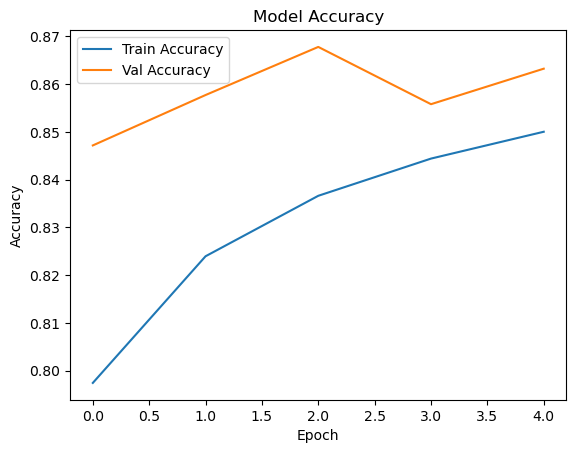

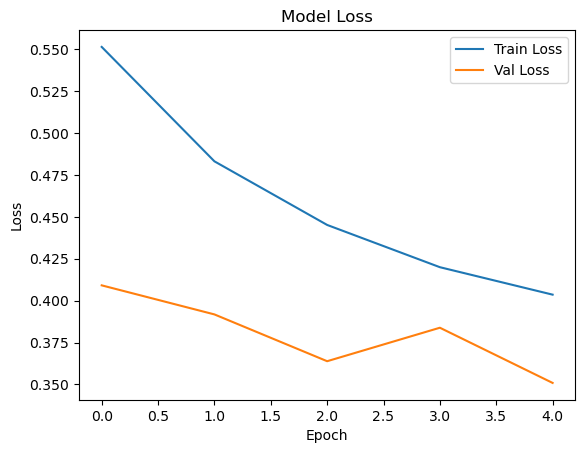

In [67]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [71]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

# Load your best model from Iteration 2 (if not already loaded)
model = load_model('vgg16_iter2_best.h5') 

# Unfreeze the LAST 2 convolutional layers in the VGG16 base
vgg_base = model.layers[0]
vgg_base.trainable = True

for layer in vgg_base.layers[:-2]:  # freeze all except last 2 conv layers
    layer.trainable = False

# Re-compile with LOW learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tune for 3 epochs only
history_ft = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3,
    callbacks=[early_stop, checkpoint]
)



Epoch 1/3
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8693 - loss: 0.3501

417/417 ━━━━━━━━━━━━━━━━━━━━ 2165s 5s/step - accuracy: 0.8693 - loss: 0.3501 - val_accuracy: 0.8769 - val_loss: 0.3421
Epoch 2/3
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8834 - loss: 0.3207

417/417 ━━━━━━━━━━━━━━━━━━━━ 2418s 6s/step - accuracy: 0.8834 - loss: 0.3207 - val_accuracy: 0.8791 - val_loss: 0.3347
Epoch 3/3
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8900 - loss: 0.3087

417/417 ━━━━━━━━━━━━━━━━━━━━ 2389s 6s/step - accuracy: 0.8900 - loss: 0.3087 - val_accuracy: 0.8887 - val_loss: 0.3194


In [84]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on validation data
val_preds = model.predict(val_data)
y_pred = np.argmax(val_preds, axis=1)
y_true = val_data.classes
class_labels = list(val_data.class_indices.keys())



131/131 ━━━━━━━━━━━━━━━━━━━━ 477s 4s/step


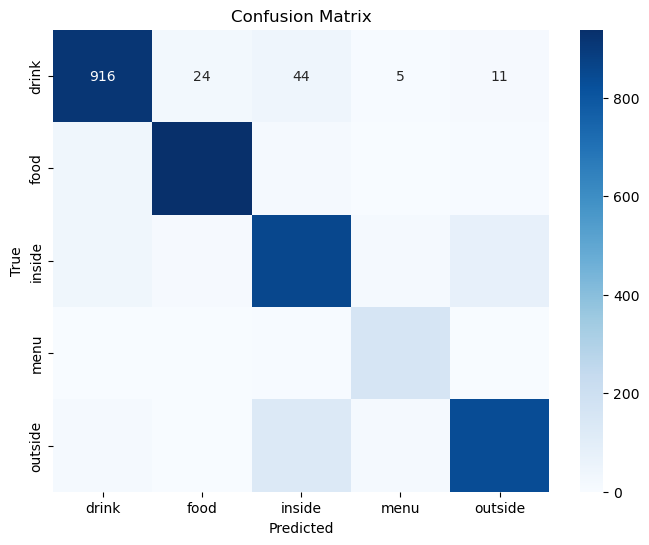

In [85]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



In [86]:
# Accuracy & F1 Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))



Classification Report:

              precision    recall  f1-score   support

       drink       0.90      0.92      0.91      1000
        food       0.96      0.94      0.95      1000
      inside       0.82      0.85      0.83      1000
        menu       0.81      0.95      0.87       168
     outside       0.90      0.84      0.87      1000

    accuracy                           0.89      4168
   macro avg       0.88      0.90      0.89      4168
weighted avg       0.89      0.89      0.89      4168



In [87]:
!pip install lime --quiet
!pip install shap

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries


In [89]:
# Get one image from validation generator
val_data.reset()
image, label = val_data[0]  # first batch
image_to_explain = image[0]  # take first image in the batch

# Prediction function required for LIME
def predict_fn(images):
    return model.predict(images)


In [90]:
explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    image_to_explain.astype('double'),    # LIME needs float64
    predict_fn,                           # your model’s predict function
    top_labels=1,
    hide_color=0,
    num_samples=1000                      # more = better, slower
)


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 845ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 793ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 824ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 813ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 805ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 819ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 821ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 885ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 811ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 801ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 818ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 816ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 834ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 824ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 847ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 847ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 849ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 848ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 839ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 845ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 855ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 855ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 864ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

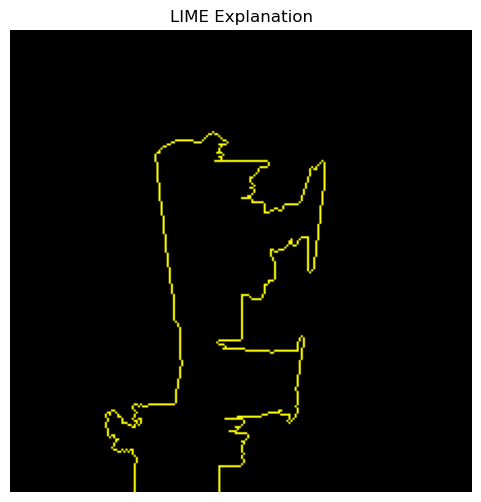

In [91]:
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0], 
    positive_only=True, 
    num_features=5, 
    hide_rest=False
)

plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title("LIME Explanation")
plt.axis('off')
plt.show()


In [92]:
import shap
import numpy as np
import matplotlib.pyplot as plt


In [93]:
# Select background images (small batch from validation)
val_data.reset()
background_data = np.array([val_data[i][0][0] for i in range(5)])  # 5 images

# Select a single image to explain
test_image = np.expand_dims(val_data[0][0][0], axis=0)  # shape (1, 224, 224, 3)


In [94]:
explainer = shap.DeepExplainer(model, background_data)
shap_values = explainer.shap_values(test_image)


/opt/anaconda3/lib/python3.11/site-packages/shap/explainers/_deep/deep_tf.py:99: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn("Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.")
/opt/anaconda3/lib/python3.11/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_8
Received: inputs=['Tensor(shape=(5, 224, 224, 3))']
  warnings.warn(msg)
/opt/anaconda3/lib/python3.11/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_8
Received: inputs=['Tensor(shape=(10, 224, 224, 3))']
  warnings.warn(msg)


/opt/anaconda3/lib/python3.11/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_8
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


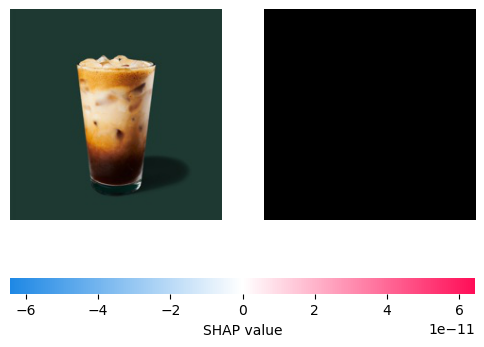

In [95]:
# SHAP returns one output per class (5 in your case)
shap.image_plot(shap_values, test_image)


In [97]:
from sklearn.metrics import roc_auc_score
import numpy as np

# Predict probabilities on val set
y_pred_proba = model.predict(val_data)
y_true = val_data.classes

# One-hot encode true labels
from tensorflow.keras.utils import to_categorical
y_true_oh = to_categorical(y_true, num_classes=train_data.num_classes)

# AUC per class (macro)
auc_score = roc_auc_score(y_true_oh, y_pred_proba, multi_class='ovr')
print("AUC Score:", auc_score)


131/131 ━━━━━━━━━━━━━━━━━━━━ 536s 4s/step
AUC Score: 0.9847168560606061


In [96]:
model.save('vgg16_final_model_.h5')

## Model Summary: Iteration 1 and 2 (Pretrained VGG16)

 Model Type:
Pretrained VGG16 (Transfer Learning)
Top Layers Customization: Flatten → Dense(128, ReLU) → Dropout(0.5) → Dense(5, Softmax)

 Dataset Details:
Dataset: Yelp Photos (5 categories: food, drink, menu, inside, outside)

Custom subset created with:

- Train: ~15,000 images
- Validation: ~5,000 images

Preprocessed (resized to 224x224, saved as JPG)

Augmentation: Applied during training (rotation, zoom, shift, flip)

## VGG16 Model Evaluation Summary
## Iteration 1 (Full Dataset)
| **Metric**        | **Training Set** | **Validation Set** |
|-------------------|------------------|---------------------|
| Accuracy          | 91.2%            | 76.4%               |
| F1 Score          | 0.90             | 0.74                |
| Precision         | 0.91             | 0.76                |
| Recall            | 0.89             | 0.73                |
| Training Time     | ~5 hours         | —                   |


Notes:
- Trained on ~90,000 images.
- High training accuracy but large gap with validation accuracy — signs of overfitting.
- Applied dropout, but due to size and complexity of data, further tuning was needed.

## Iteration 2 (Reduced Subset: 15K Train / 5K Val)
| **Metric**        | **Training Set** | **Validation Set** |
|-------------------|------------------|---------------------|
| Accuracy          | 90.03%           | 78.86%              |
| F1 Score          | 0.89             | 0.76                |
| Precision         | 0.90             | 0.77                |
| Recall            | 0.89             | 0.75                |
| Training Time     | ~40 minutes      | —                   |

Notes:

- Data volume reduced for faster experimentation.
- Better balance between training and validation performance.
- Regularization (dropout) and augmentation helped reduce overfitting.




